In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Put the local CAMB-Rayleigh checkout at the front of sys.path so `import camb`
# picks up this fork (with its compiled camblib.so) rather than any pip-installed camb.
CAMB_RAYLEIGH_DIR = Path("../CAMB-Rayleigh").resolve()
if str(CAMB_RAYLEIGH_DIR) not in sys.path:
    sys.path.insert(0, str(CAMB_RAYLEIGH_DIR))

import camb

print("camb module path:", camb.__file__)
print("camb version:", camb.__version__)

camb module path: /Users/kwanitgangopadhyay/Desktop/PhD/Code/CAMB-Rayleigh/camb/__init__.py
camb version: 2.0.0


In [2]:
INI_PATH = CAMB_RAYLEIGH_DIR / "inifiles" / "planck_2018.ini"

pars = camb.read_ini(str(INI_PATH))
pars.DoLensing = False  # Haven't yet added the lensed Rayleigh Cls, so Lensing is off
pars.SourceTerms.rayleigh_scattering = True # Rayleigh scattering turned on
pars.SourceTerms.rayleigh_frequencies = [143, 217, 353, 545, 857] 
results = camb.get_results(pars)
freqs = list(pars.SourceTerms.rayleigh_frequencies)

derived = results.get_derived_params()
print(f"z_star (recombination):    {derived['zstar']:.2f}")
print(f"r_star (sound horizon):    {derived['rstar']:.4f} Mpc")
print(f"z_drag:                    {derived['zdrag']:.2f}")
print(f"100*theta_star:            {derived['thetastar']:.6f}")
print(f"sigma_8 (today):           {results.get_sigma8_0():.4f}")
print("Bands:", freqs, "GHz")

z_star (recombination):    1089.91
r_star (sound horizon):    144.3947 Mpc
z_drag:                    1059.97
100*theta_star:            1.041084
sigma_8 (today):           0.8118
Bands: [143.0, 217.0, 353.0, 545.0, 857.0] GHz


In [3]:
cls = results.get_rayleigh_cls(CMB_unit="muK")
ell = np.arange(cls.shape[2])
np.shape(cls)

(6, 6, 2701, 4)

### How to access the various power spectra?
the array `cls = results.get_rayleigh_cls(CMB_unit="muK")` has shape `(f+1,f+1,lmax,4)`
- `f` is the number of frequency channels, for Planck it is 5, the bands being [143, 217, 353, 545, 857] GHz
- `f+1` channels because the first (index `0`) channel is reserved for the Primary, and the next `f` channels for the `f` frequencies
- the combination of first two rows provides which cross-spectrum we need. For example, `(0,0)` is just the Primary, `(0,4)` is the Primary x Rayleigh at $\nu = 545$ GHz (the 4th frequency channel), `(2,2)` is the Rayleigh auto spectrum at frequency $\nu = 217$ GHz (the 2nd frequency channel), and `(1,5)` is the Rayleigh cross Rayleigh spectrum at frequencies $143$ GHz $\times$ $857$ (the 1st frequency channel cross 5th frequency channel)
- the third row of `cl` contains the $C_\ell$'s for every $\ell$ value provided
- the fourth row of `cl` is for specifying which $C_\ell$ one needs: 0 for TT, 1 for EE, 2 for BB and 3 for TE

Text(0.5, 1.0, 'Primary x Rayleigh-channel cross-spectra (TT)')

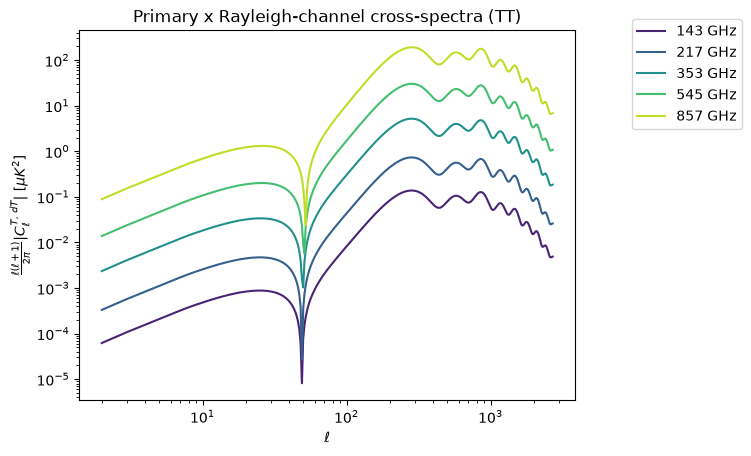

In [4]:
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(freqs)))

plt.loglog(ell[2:], np.abs(cls[0,1,2:,0]),label='143 GHz', color = colors[0])

plt.loglog(ell[2:], np.abs(cls[0,2,2:,0]),label='217 GHz', color = colors[1])

plt.loglog(ell[2:], np.abs(cls[0,3,2:,0]),label='353 GHz', color = colors[2])

plt.loglog(ell[2:], np.abs(cls[0,4,2:,0]),label='545 GHz', color = colors[3])

plt.loglog(ell[2:], np.abs(cls[0,5,2:,0]),label='857 GHz', color = colors[4])

plt.legend(bbox_to_anchor=(1.1, 1.05))
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\frac{\ell(\ell+1)}{2\pi}|C_\ell^{T,\,dT}|$ [$\mu K^2$]")
plt.title("Primary x Rayleigh-channel cross-spectra (TT)")

Text(0.5, 1.0, 'Rayleigh-channel auto-spectra (TT)')

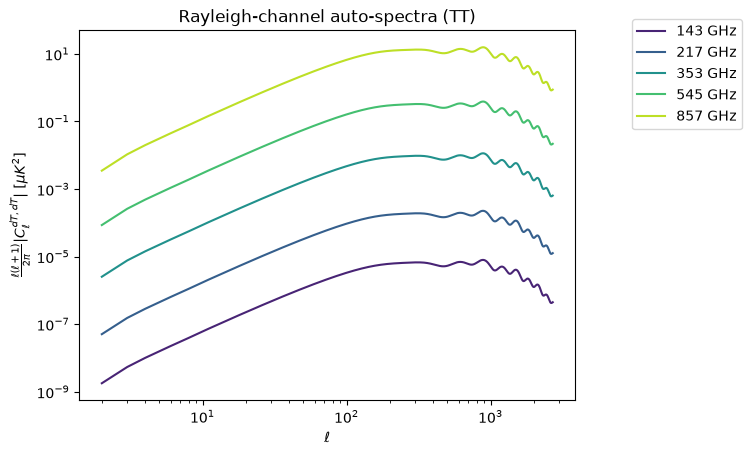

In [5]:
plt.loglog(ell[2:], np.abs(cls[1,1,2:,0]),label='143 GHz', color = colors[0])

plt.loglog(ell[2:], np.abs(cls[2,2,2:,0]),label='217 GHz', color = colors[1])

plt.loglog(ell[2:], np.abs(cls[3,3,2:,0]),label='353 GHz', color = colors[2])

plt.loglog(ell[2:], np.abs(cls[4,4,2:,0]),label='545 GHz', color = colors[3])

plt.loglog(ell[2:], np.abs(cls[5,5,2:,0]),label='857 GHz', color = colors[4])

plt.legend(bbox_to_anchor=(1.1, 1.05))
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\frac{\ell(\ell+1)}{2\pi}|C_\ell^{dT,dT}|$ [$\mu K^2$]")
plt.title("Rayleigh-channel auto-spectra (TT)")

Text(0.5, 1.0, 'Primary x Rayleigh-channel cross-spectra (TE)')

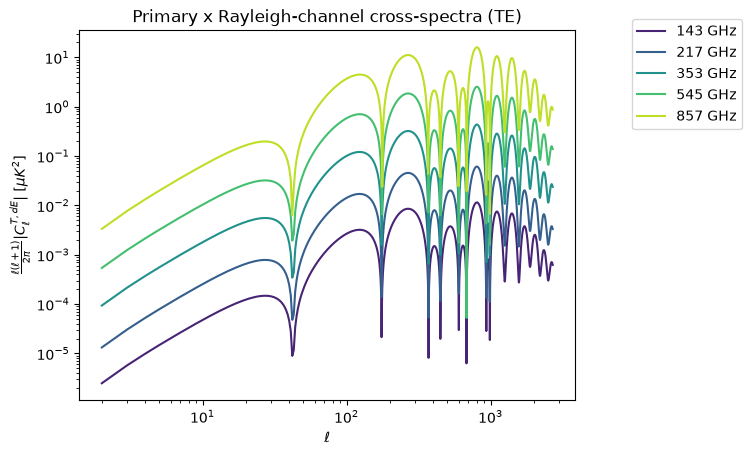

In [6]:
plt.loglog(ell[2:], np.abs(cls[0,1,2:,3]),label='143 GHz', color = colors[0])

plt.loglog(ell[2:], np.abs(cls[0,2,2:,3]),label='217 GHz', color = colors[1])

plt.loglog(ell[2:], np.abs(cls[0,3,2:,3]),label='353 GHz', color = colors[2])

plt.loglog(ell[2:], np.abs(cls[0,4,2:,3]),label='545 GHz', color = colors[3])

plt.loglog(ell[2:], np.abs(cls[0,5,2:,3]),label='857 GHz', color = colors[4])

plt.legend(bbox_to_anchor=(1.1, 1.05))
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\frac{\ell(\ell+1)}{2\pi}|C_\ell^{T,dE}|$ [$\mu K^2$]")
plt.title("Primary x Rayleigh-channel cross-spectra (TE)")

Text(0.5, 1.0, 'Rayleigh x Primary-channel cross-spectra (TE)')

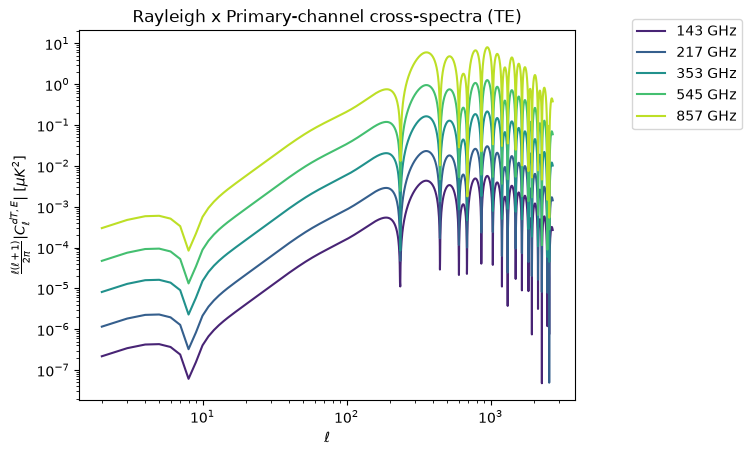

In [7]:
plt.loglog(ell[2:], np.abs(cls[1,0,2:,3]),label='143 GHz', color = colors[0])

plt.loglog(ell[2:], np.abs(cls[2,0,2:,3]),label='217 GHz', color = colors[1])

plt.loglog(ell[2:], np.abs(cls[3,0,2:,3]),label='353 GHz', color = colors[2])

plt.loglog(ell[2:], np.abs(cls[4,0,2:,3]),label='545 GHz', color = colors[3])

plt.loglog(ell[2:], np.abs(cls[5,0,2:,3]),label='857 GHz', color = colors[4])

plt.legend(bbox_to_anchor=(1.1, 1.05))
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\frac{\ell(\ell+1)}{2\pi}|C_\ell^{dT,E}|$ [$\mu K^2$]")
plt.title("Rayleigh x Primary-channel cross-spectra (TE)")

Text(0.5, 1.0, 'Primary x Rayleigh-channel cross-spectra (EE)')

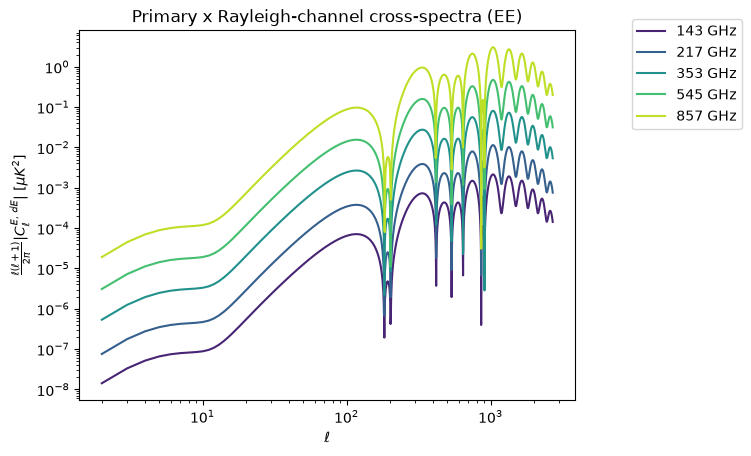

In [8]:
plt.loglog(ell[2:], np.abs(cls[0,1,2:,1]),label='143 GHz', color = colors[0])

plt.loglog(ell[2:], np.abs(cls[0,2,2:,1]),label='217 GHz', color = colors[1])

plt.loglog(ell[2:], np.abs(cls[0,3,2:,1]),label='353 GHz', color = colors[2])

plt.loglog(ell[2:], np.abs(cls[0,4,2:,1]),label='545 GHz', color = colors[3])

plt.loglog(ell[2:], np.abs(cls[0,5,2:,1]),label='857 GHz', color = colors[4])

plt.legend(bbox_to_anchor=(1.1, 1.05))
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\frac{\ell(\ell+1)}{2\pi}|C_\ell^{E,\,dE}|$ [$\mu K^2$]")
plt.title("Primary x Rayleigh-channel cross-spectra (EE)")

Text(0.5, 1.0, 'Rayleigh-channel auto-spectra (EE)')

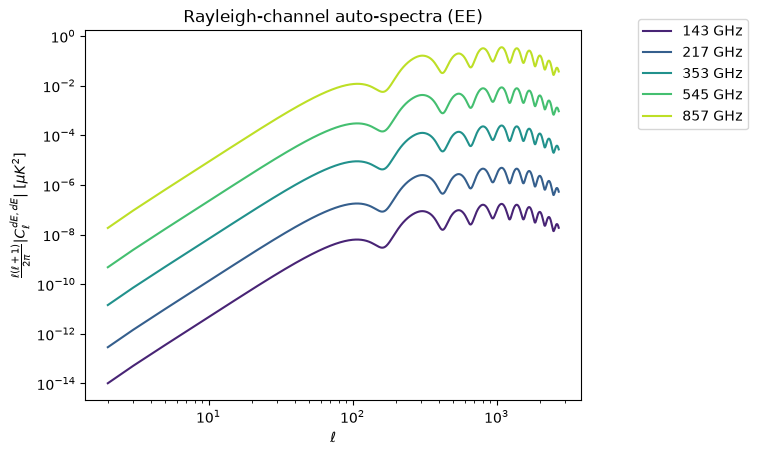

In [9]:
plt.loglog(ell[2:], np.abs(cls[1,1,2:,1]),label='143 GHz', color = colors[0])

plt.loglog(ell[2:], np.abs(cls[2,2,2:,1]),label='217 GHz', color = colors[1])

plt.loglog(ell[2:], np.abs(cls[3,3,2:,1]),label='353 GHz', color = colors[2])

plt.loglog(ell[2:], np.abs(cls[4,4,2:,1]),label='545 GHz', color = colors[3])

plt.loglog(ell[2:], np.abs(cls[5,5,2:,1]),label='857 GHz', color = colors[4])

plt.legend(bbox_to_anchor=(1.1, 1.05))
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\frac{\ell(\ell+1)}{2\pi}|C_\ell^{dE,dE}|$ [$\mu K^2$]")
plt.title("Rayleigh-channel auto-spectra (EE)")

### Accessing the Visibility and Opacity functions for various frequencies

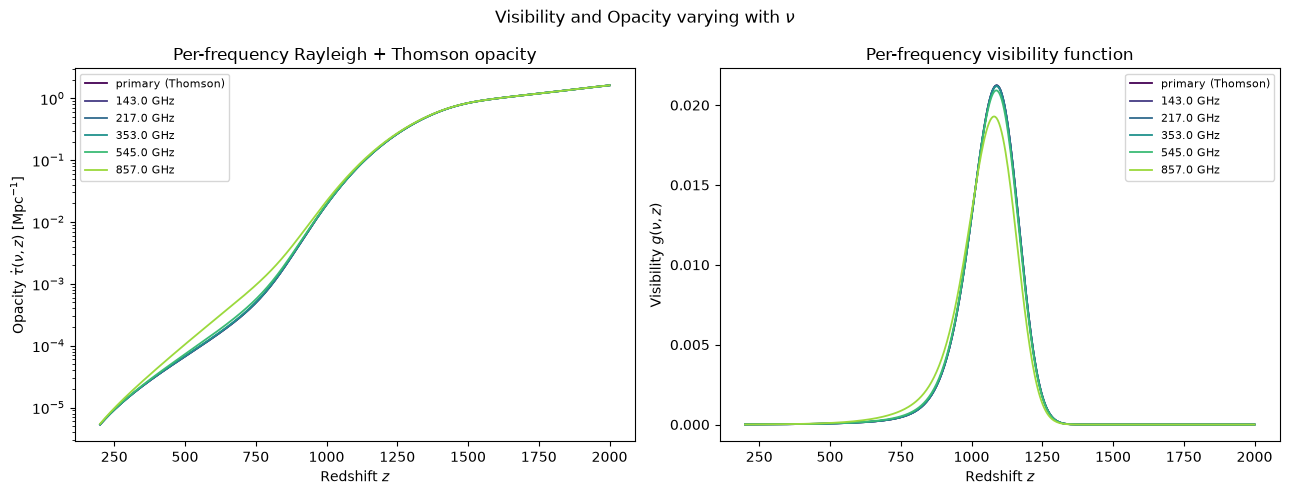

In [12]:
z_grid = np.linspace(200, 2000, 400)
eta_grid = results.conformal_time(z_grid)
evo = results.get_rayleigh_thermal_evolution(eta_grid)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ["primary (Thomson)"] + [f"{b} GHz" for b in freqs]
colors = plt.cm.viridis(np.linspace(0, 0.85, len(labels)))

for i, (label, color) in enumerate(zip(labels, colors)):
    axes[0].plot(z_grid, evo["opacity"][:, i], color=color, label=label, lw=1.3)
    axes[1].plot(z_grid, evo["visibility"][:, i], color=color, label=label, lw=1.3)

axes[0].set_yscale("log")
axes[0].set_xlabel("Redshift $z$")
axes[0].set_ylabel(r"Opacity $\dot\tau(\nu, z)$ [Mpc$^{-1}$]")
axes[0].set_title("Per-frequency Rayleigh + Thomson opacity")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Redshift $z$")
axes[1].set_ylabel(r"Visibility $g(\nu, z)$")
axes[1].set_title("Per-frequency visibility function")
axes[1].legend(fontsize=8)

fig.suptitle(r"Visibility and Opacity varying with $\nu$")
fig.tight_layout()
plt.show()

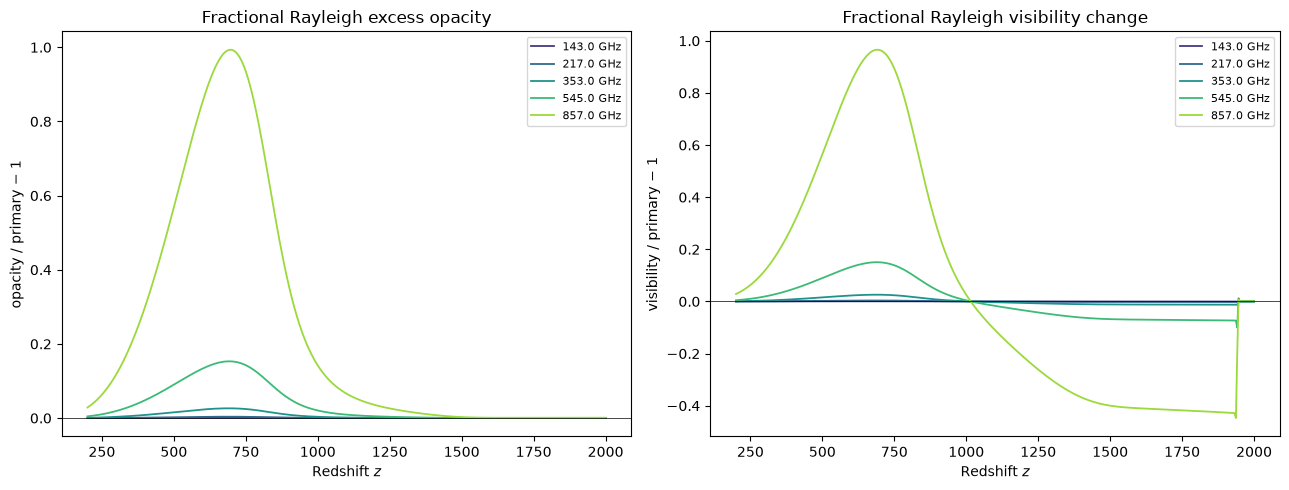

In [14]:
# zoom on the fractional difference from the primary, where the actual physics is
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, (band, color) in enumerate(zip(freqs, colors[1:])):
    frac_opac = evo["opacity"][:, i + 1] / evo["opacity"][:, 0] - 1
    frac_vis = evo["visibility"][:, i + 1] / evo["visibility"][:, 0] - 1
    axes[0].plot(z_grid, frac_opac, color=color, label=f"{band} GHz", lw=1.3)
    axes[1].plot(z_grid, frac_vis, color=color, label=f"{band} GHz", lw=1.3)

for ax, name in zip(axes, ["opacity", "visibility"]):
    ax.set_xlabel("Redshift $z$")
    ax.set_ylabel(f"{name} / primary $-$ 1")
    ax.legend(fontsize=8)
    ax.axhline(0, color="k", lw=0.5)
axes[0].set_title("Fractional Rayleigh excess opacity")
axes[1].set_title("Fractional Rayleigh visibility change")
fig.tight_layout()
plt.show()